# 02 - Padded Linear Convolution, PGD, and FISTA

The DFT based circular convolution model is mathematically convenient, but real sensors do not wrap light around image boundaries. This notebook builds the padded linear operator, verifies the adjoint, runs projected gradient descent and FISTA, and saves the reusable figures and evaluate the results.


## Setup

In [1]:
from pathlib import Path
import sys
import json

import numpy as np
from PIL import Image

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'src' / 'diffusercam_sim').exists():
            return candidate
    raise RuntimeError('Could not find project root containing src/diffusercam_sim')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from diffusercam_sim import (
    PaddedLinearConvolution,
    add_gaussian_noise,
    fista,
    make_diffuser_like_psf,
    make_synthetic_scene,
    projected_gradient_descent,
    residual_relative_l2,
)
from diffusercam_sim.viz import save_convergence_plot, save_montage

RESULT_DIR = PROJECT_ROOT / 'results' / 'notebooks' / '02_padded_linear_pgd_fista'
RESULT_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT

WindowsPath('E:/RIT/Spring2026/ComputationalImaging/DiffuserCam2026')

## Build the Forward Operator

The operator object stores the padding/cropping geometry, the padded PSF, the FFT transfer function, and the adjoint operator. This is cleaner than scattering FFT details through the notebook.

In [4]:
image_size = 256
scene = make_synthetic_scene(image_size)
psf = make_diffuser_like_psf(image_size)
operator = PaddedLinearConvolution(psf)

{
    'image_shape': operator.image_shape,
    'padded_shape': operator.padded_shape,
    'lipschitz_bound': operator.lipschitz_bound,
}

{'image_shape': (256, 256),
 'padded_shape': (512, 512),
 'lipschitz_bound': 0.9999999999999993}

## Simulate a Measurement

The measurement is a cropped linear convolution plus Gaussian noise.

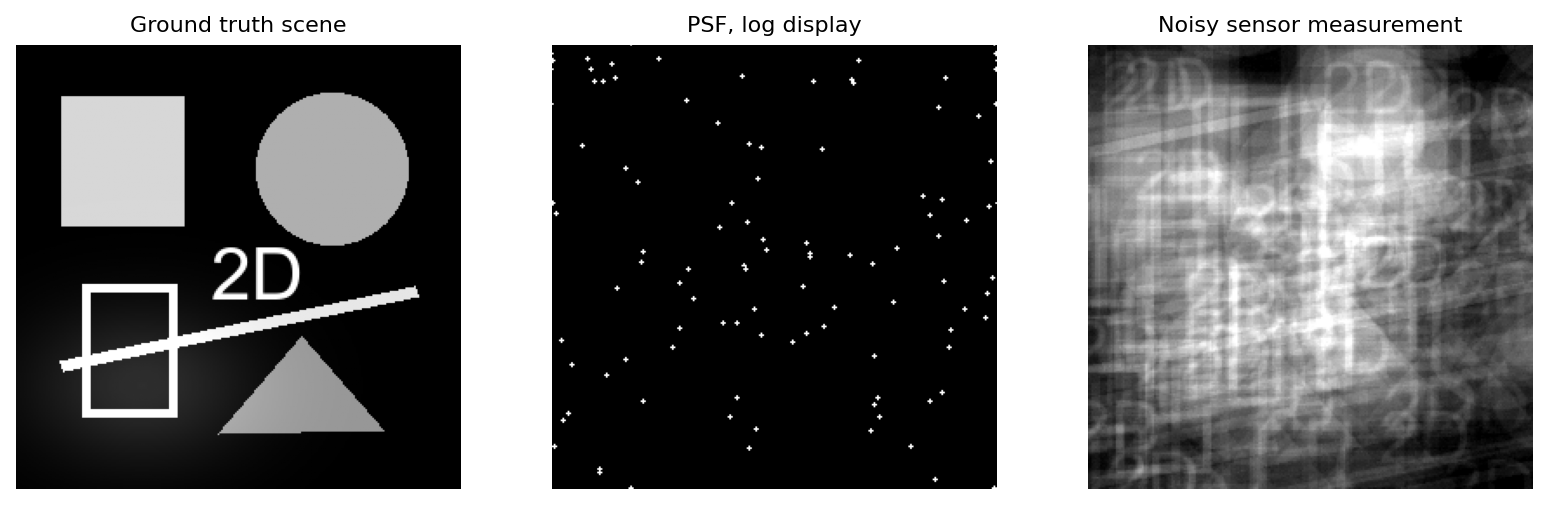

In [5]:
snr_db = 35.0
clean_measurement = operator.forward(scene)
measurement, noise_sigma = add_gaussian_noise(clean_measurement, snr_db)

save_montage(
    [
        ('Ground truth scene', scene),
        ('PSF, log display', psf),
        ('Noisy sensor measurement', measurement),
    ],
    RESULT_DIR / 'forward_model.png',
    columns=3,
)
Image.open(RESULT_DIR / 'forward_model.png')

## Adjoint Check

For iterative reconstruction, the gradient is:

$$ \nabla f(x) = A^H(Ax - b) $$

That only works if `A^H` is the true adjoint. We verify:

$$ \langle Ax, y \rangle = \langle x, A^H y \rangle $$

In [6]:
adjoint_error = operator.adjoint_inner_product_error()
adjoint_error

3.013635081837792e-15

## Projected Gradient Descent

We solve a nonnegative least-squares problem:

$$ \min_x \frac{1}{2}\|Ax-b\|_2^2 \quad \text{subject to } x \ge 0 $$

The update is:

$$ x_{k+1} = \max(x_k - \alpha A^H(Ax_k-b), 0) $$

In [7]:
iterations = 80
record_every = 5

pgd_result = projected_gradient_descent(
    operator=operator,
    measurement=measurement,
    iterations=iterations,
    truth=scene,
    record_every=record_every,
)

pgd_result.history[-1]

IterationRecord(iteration=80, objective=1.8521840850888824, relative_residual_l2=0.04981650592019043, psnr_db=15.412753778359438, ssim=0.3152240945923163)

## FISTA

FISTA uses the same gradient and nonnegativity projection, but adds a momentum point. This often reaches a useful reconstruction in fewer iterations.

In [8]:
fista_result = fista(
    operator=operator,
    measurement=measurement,
    iterations=iterations,
    truth=scene,
    record_every=record_every,
)

fista_result.history[-1]

IterationRecord(iteration=80, objective=0.08556994406222523, relative_residual_l2=0.010707591967304452, psnr_db=21.167045221242418, ssim=0.4865721291437751)

## Compare Reconstructions

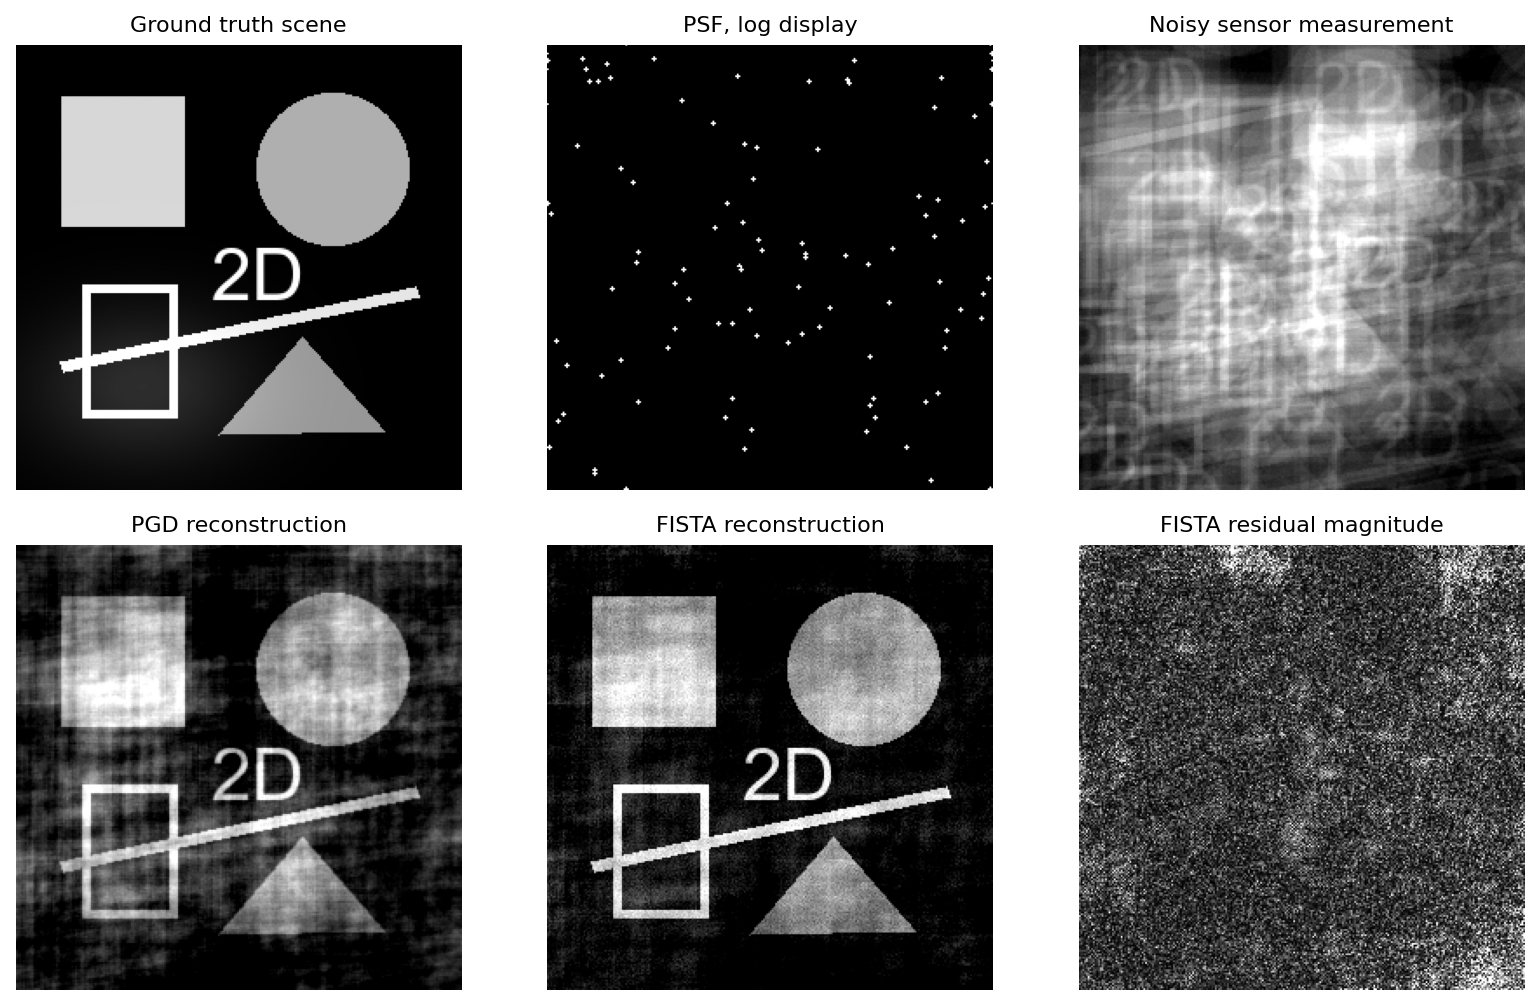

In [9]:
pgd_predicted = operator.forward_padded(pgd_result.padded_estimate)
fista_predicted = operator.forward_padded(fista_result.padded_estimate)
pgd_residual = pgd_predicted - measurement
fista_residual = fista_predicted - measurement

save_montage(
    [
        ('Ground truth scene', scene),
        ('PSF, log display', psf),
        ('Noisy sensor measurement', measurement),
        ('PGD reconstruction', pgd_result.reconstruction),
        ('FISTA reconstruction', fista_result.reconstruction),
        ('FISTA residual magnitude', np.abs(fista_residual)),
    ],
    RESULT_DIR / 'reconstruction_montage.png',
    columns=3,
)
Image.open(RESULT_DIR / 'reconstruction_montage.png')

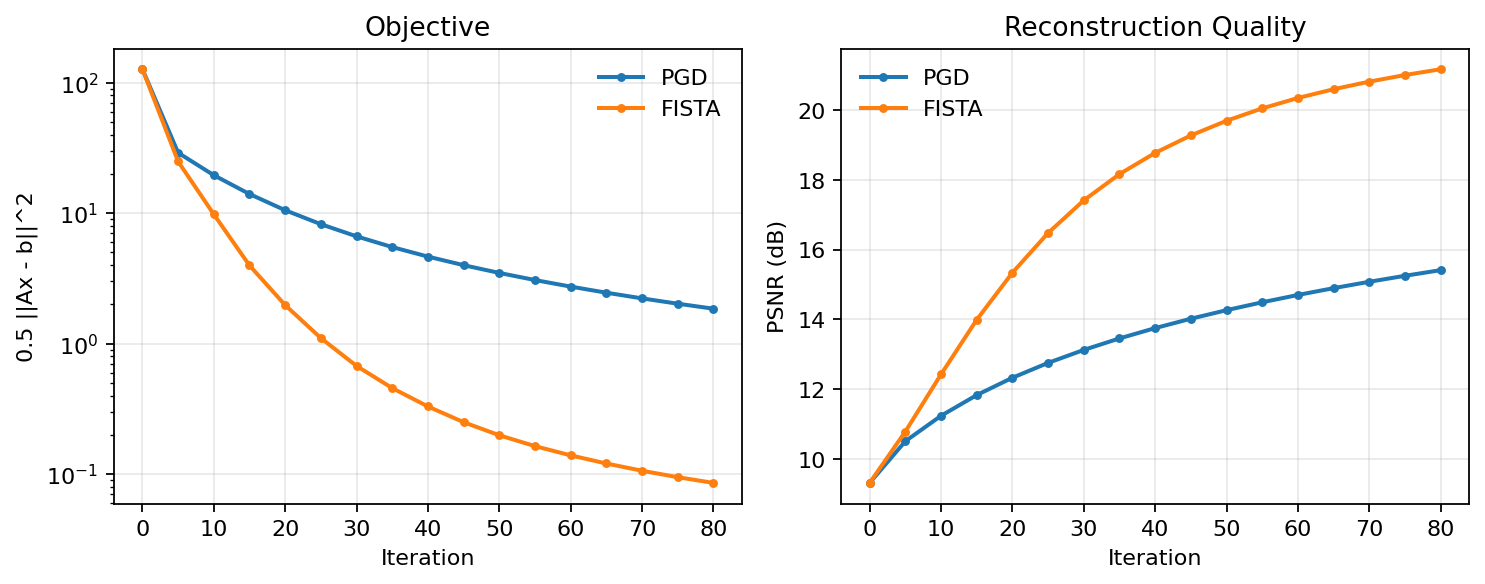

In [10]:
save_convergence_plot(
    [('PGD', pgd_result.history), ('FISTA', fista_result.history)],
    RESULT_DIR / 'convergence.png',
)
Image.open(RESULT_DIR / 'convergence.png')

In [11]:
summary = {
    'model': 'padded linear convolution with centered sensor crop',
    'image_shape': operator.image_shape,
    'padded_shape': operator.padded_shape,
    'snr_db': snr_db,
    'noise_sigma': noise_sigma,
    'adjoint_error': adjoint_error,
    'step_size': pgd_result.step_size,
    'iterations': iterations,
    'record_every': record_every,
    'pgd_final': pgd_result.history[-1].__dict__,
    'fista_final': fista_result.history[-1].__dict__,
    'pgd_padded_estimate_forward_residual_l2': residual_relative_l2(measurement, pgd_predicted),
    'fista_padded_estimate_forward_residual_l2': residual_relative_l2(measurement, fista_predicted),
}
(RESULT_DIR / 'summary.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')
np.savez_compressed(
    RESULT_DIR / 'iterative_2d_arrays.npz',
    scene=scene,
    psf=psf,
    clean_measurement=clean_measurement,
    measurement=measurement,
    pgd_reconstruction=pgd_result.reconstruction,
    fista_reconstruction=fista_result.reconstruction,
    pgd_residual=pgd_residual,
    fista_residual=fista_residual,
)
print(json.dumps(summary, indent=2))

{
  "model": "padded linear convolution with centered sensor crop",
  "image_shape": [
    256,
    256
  ],
  "padded_shape": [
    512,
    512
  ],
  "snr_db": 35.0,
  "noise_sigma": 0.0026835363748452055,
  "adjoint_error": 3.013635081837792e-15,
  "step_size": 1.8000000000000012,
  "iterations": 80,
  "record_every": 5,
  "pgd_final": {
    "iteration": 80,
    "objective": 1.8521840850888824,
    "relative_residual_l2": 0.04981650592019043,
    "psnr_db": 15.412753778359438,
    "ssim": 0.3152240945923163
  },
  "fista_final": {
    "iteration": 80,
    "objective": 0.08556994406222523,
    "relative_residual_l2": 0.010707591967304452,
    "psnr_db": 21.167045221242418,
    "ssim": 0.4865721291437751
  },
  "pgd_padded_estimate_forward_residual_l2": 0.04981650592019043,
  "fista_padded_estimate_forward_residual_l2": 0.010707591967304452
}


## Saved


In [12]:
import csv

def write_history_csv(path: Path, method: str, records: list[object]) -> None:
    fieldnames = ['method', 'iteration', 'objective', 'relative_residual_l2', 'psnr_db', 'ssim']
    with path.open('w', newline='', encoding='utf-8') as csv_file:
        writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
        writer.writeheader()
        for record in records:
            row = dict(record.__dict__)
            row['method'] = method
            writer.writerow(row)

write_history_csv(RESULT_DIR / 'pgd_history.csv', pgd_result.method, pgd_result.history)
write_history_csv(RESULT_DIR / 'fista_history.csv', fista_result.method, fista_result.history)

[artifact.name for artifact in sorted(RESULT_DIR.glob('*'))]

['convergence.png',
 'fista_history.csv',
 'forward_model.png',
 'iterative_2d_arrays.npz',
 'pgd_history.csv',
 'reconstruction_montage.png',
 'summary.json']

## Observation

- FISTA should usually beat PGD at the same iteration count because momentum accelerates convergence.